In [51]:
#0. 작업 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#데이터 분할
from sklearn.model_selection import train_test_split
#모델 모듈(딥러닝)
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,Dropout,SimpleRNN,LSTM,GRU,BatchNormalization,Flatten
from keras.optimizers import Adam,RMSprop,SGD,Adagrad
from keras.losses import binary_crossentropy,categorical_crossentropy,sparse_categorical_crossentropy,mean_squared_error
#모델 학습
from keras.callbacks import EarlyStopping,ModelCheckpoint
#모델 로드
from keras.models import load_model
#성능검토
from sklearn.metrics import r2_score,classification_report,f1_score,mean_squared_error
from tensorflow import truediv

In [52]:
from keras.datasets import fashion_mnist
(x_data,y_data),(tt_x,tt_y) = fashion_mnist.load_data()

In [53]:
tr_x, val_x, tr_y, val_y = train_test_split(x_data, y_data, test_size=0.2)

In [54]:
s_tr_x = tr_x/255
s_tt_x = tt_x/255
s_val_x = val_x/255

In [55]:
e_tr_x = s_tr_x.reshape(-1, 28, 28, 1)
e_tt_x = s_tt_x.reshape(-1, 28, 28, 1)
e_val_x = s_val_x.reshape(-1, 28, 28, 1)

In [56]:
from keras.utils import to_categorical
e_tr_y=to_categorical(tr_y)
e_tt_y=to_categorical(tt_y)
e_val_y=to_categorical(val_y)

In [57]:
# e_tr_y = tr_y.reshape(-1, 1)

In [58]:
e_tr_x.shape, e_tr_y.shape

((48000, 28, 28, 1), (48000, 10))

In [59]:
# CNN model
m = Sequential()
m.add(Input(shape=e_tr_x.shape[1:])) # 28, 28, 1
m.add(Conv2D(32, 3, 1, padding='same', activation='relu')) # 28, 28, 32
m.add(MaxPooling2D(2)) # 14, 14, 32
m.add(Conv2D(64, 3, 1, padding='same', activation='relu')) # 14, 14, 64
m.add(MaxPooling2D(2)) # 7, 7, 64
m.add(Conv2D(128, 3, 1, padding='same', activation='relu')) # 7, 7, 128
m.add(MaxPooling2D(2)) # 3, 3, 128
m.add(Conv2D(256, 3, 1, padding='same', activation='relu')) # 3, 3, 256
m.add(MaxPooling2D(2)) # 1, 1, 256 <- 여기까진 이미지로 남아있다
m.add(Flatten()) # 여기서 벡터로 변환

m.add(Dense(100, activation='relu'))
m.add(Dense(10, activation='softmax'))

m.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        25,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,550 (1.58 MB)

 Trainable params: 414,550 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

In [60]:
m.predict(e_tr_x).shape# 초기 가중치가 설정되어 있다.

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


(48000, 10)

In [61]:
e_tr_y.shape

(48000, 10)

In [62]:
py = m.predict(e_tr_x)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [63]:
ty = e_tr_y

In [64]:
np.argmax(py, axis=1)

array([6, 6, 6, ..., 6, 6, 6])

In [65]:
ty[0]>0.5

array([False, False, False, False,  True, False, False, False, False,
       False])

In [66]:
np.argmax(ty, axis=1)

array([4, 2, 7, ..., 9, 3, 3])

In [67]:
print(classification_report(np.argmax(py, axis=1),np.argmax(ty, axis=1)))

              precision    recall  f1-score   support

           0       0.06      0.19      0.10      1569
           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           5       0.00      0.00      0.00         0
           6       0.91      0.09      0.17     46360
           7       0.00      0.00      0.00         0
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00        71

    accuracy                           0.10     48000
   macro avg       0.10      0.03      0.03     48000
weighted avg       0.88      0.10      0.17     48000



/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/stenv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
m.compile(loss='categorical_crossentropy', metrics=['acc'])

In [ ]:
hy = m.fit(e_tr_x, e_tr_y, validation_split=0.2, epochs=10)

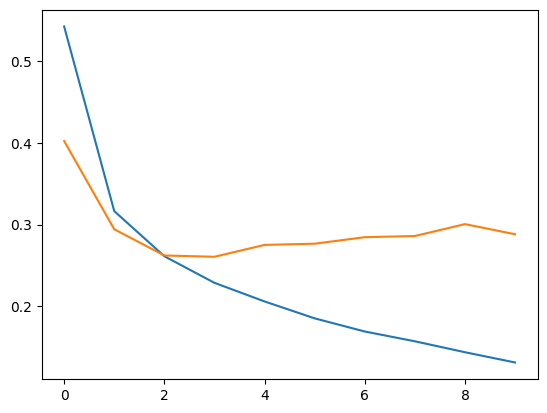

In [70]:
plt.plot(hy.history['loss'])
plt.plot(hy.history['val_loss'])

In [71]:
tr_scs = m.evaluate(e_tr_x, e_tr_y)
val_scs = m.evaluate(e_val_x, e_val_y)
tt_scs = m.evaluate(e_tt_x, e_tt_y)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - acc: 0.9598 - loss: 0.1139
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.9160 - loss: 0.2787
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.9078 - loss: 0.3298


In [72]:
tr_scs

[0.1479460597038269, 0.9505000114440918]

In [73]:
all_acc = abs(tr_scs[1]-val_scs[1])+abs(tr_scs[1]+tt_scs[1])+abs(val_scs[1]-val_scs[1])
all_acc

1.8926166892051697

In [74]:
all_loss = abs(tr_scs[0]-val_scs[0])+abs(tr_scs[0]+tt_scs[0])+abs(val_scs[0]-val_scs[0])
all_loss

0.5849781930446625

In [75]:
np.abs([1, -2, 3])

array([1, 2, 3])